**PRAICP-1000 Indian Sign Langauge(ISL)**

**Domain Analysis**
* Indian sign language is a visual gestural language used by the deaf and hard-of-hearing community in India.
* Unlike spoken language, ISL relies on hand gestures, facial expressions and body movements to convey meaning.

**Project Goal:**
To Develop an AI-Based system that can recognize ISL gestures and convert theinto text or speech to bridge the communication gap.

**Technical approach for this project:**

* Problem understanding (Domain Analysis)
* Load the dataset
* Basic Checks
* Exploratory Data Analysis
* Data Preprocessing
* Feature Extraction
* Model Techniques
* Model Evaluation
* Conclusion
* Business Imapct
* Future Scope


In [ ]:
# Import all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,roc_curve,auc

**Mount drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = ('/content/drive/MyDrive/Artificaial Intelligence Capstone Project Files/PRAICP-1000-IndiSignLang/Data')
if not os.path.exists(data_path):
  print(f"Path not found: '{data_path}'")
elif os.path.isfile(data_path):
  data = pd.read_csv(data_path)
  print(f"Shape :  {data.shape}")
elif os.path.isdir(data_path):
  print(f"Directory Content { os.listdir(data_path)}")

Directory Content ['A', 'D', 'C', 'B', 'E', 'P', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'S', 'R', 'Q', 'U', 'T', 'V', 'W', 'X', 'Y']


**Basic Checks**

In [ ]:
# Check the number of classes , images and count the images per class
classes = os.listdir(data_path)
print('Classes:',classes)
print('Total Classes:',(len(classes)))
for cls in classes:
  print(cls,".",len(os.listdir(os.path.join(data_path,cls))))

Classes: ['A', 'D', 'C', 'B', 'E', 'P', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'S', 'R', 'Q', 'U', 'T', 'V', 'W', 'X', 'Y']
Total Classes: 24
A . 242
D . 147
C . 247
B . 259
E . 243
P . 234
F . 226
G . 241
H . 116
I . 179
K . 245
L . 182
M . 235
N . 237
O . 229
S . 229
R . 211
Q . 216
U . 135
T . 216
V . 122
W . 128
X . 202
Y . 251


**Exploratory Data Analysis(EDA)**

In [ ]:
# Check Basic class information
classes = sorted(os.listdir(data_path))
print(f'Total Classes:,{len(classes)}')
print(f'Classes:,{classes}')

Total Classes:,24
Classes:,['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [ ]:
# Check the count of image per class
class_counts = {}
for cls in classes:
  cls_path = os.path.join(data_path,cls)
  class_counts[cls] = len(os.listdir(cls_path))
  print(f'{cls} : {class_counts[cls]} images')
print(f'\n Total Images : {sum(class_counts.values())}')
print(f'Min images in a class : {min(class_counts.values())}')
print(f'Max images in a class : {max(class_counts.values())}')

A : 242 images
B : 259 images
C : 247 images
D : 147 images
E : 243 images
F : 226 images
G : 241 images
H : 116 images
I : 179 images
K : 245 images
L : 182 images
M : 235 images
N : 237 images
O : 229 images
P : 234 images
Q : 216 images
R : 211 images
S : 229 images
T : 216 images
U : 135 images
V : 122 images
W : 128 images
X : 202 images
Y : 251 images

 Total Images : 4972
Min images in a class : 116
Max images in a class : 259


Class Distribution:


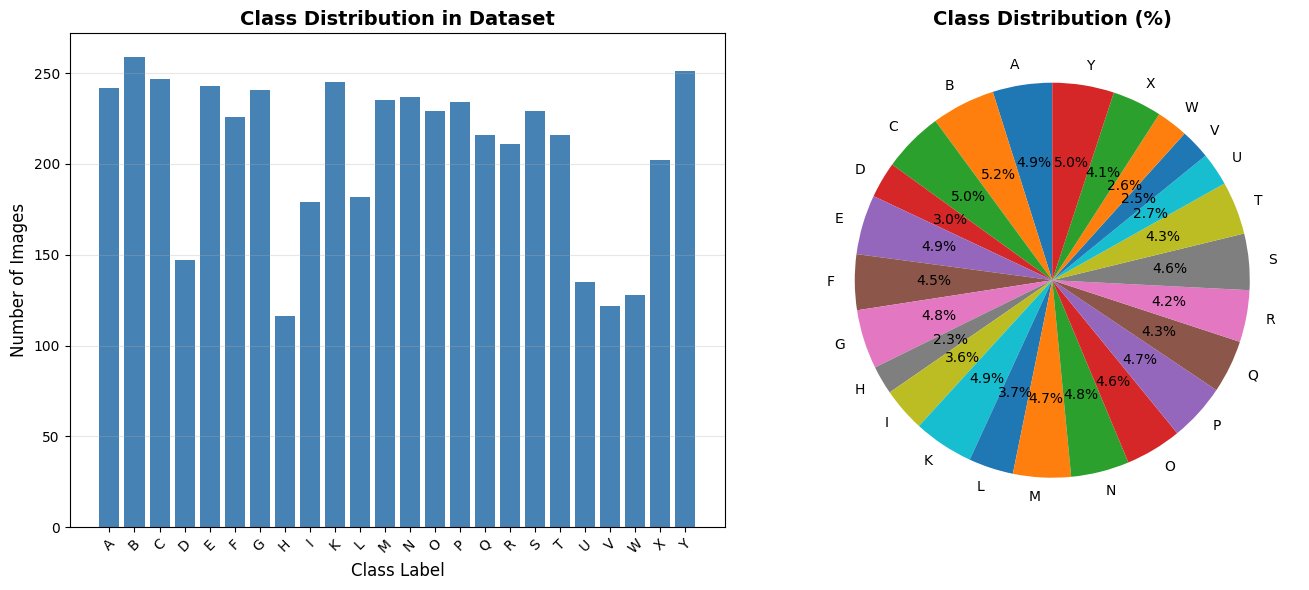


Total images: 4972
Number of classes: 24
Images per class - Min: 116, Max: 259, Mean: 207.2

Class balance ratio: 2.23:1
⚠️ Data imbalance detected - consider class weights or augmentation


In [ ]:
# 1. Class Distribution Analysis
print("Class Distribution:")

# Use the 'class_counts' dictionary computed in a previous cell (6CXObf81rKej)
# Convert the dictionary to a pandas Series for consistent plotting logic
class_counts_series = pd.Series(class_counts).sort_index()
class_labels = list(class_counts_series.index)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.bar(range(len(class_counts_series)), class_counts_series.values, color='steelblue')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_counts_series)), class_labels, rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
percentages = (class_counts_series.values / class_counts_series.sum() * 100)
plt.pie(percentages, labels=class_labels, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal images: {class_counts_series.sum()}")
print(f"Number of classes: {len(class_counts_series)}")
print(f"Images per class - Min: {class_counts_series.min()}, Max: {class_counts_series.max()}, Mean: {class_counts_series.mean():.1f}")
print(f"\nClass balance ratio: {class_counts_series.max() / class_counts_series.min():.2f}:1")

if class_counts_series.max() / class_counts_series.min() > 2:
    print("⚠️ Data imbalance detected - consider class weights or augmentation")
else:
    print("✓ Classes are reasonably balanced")

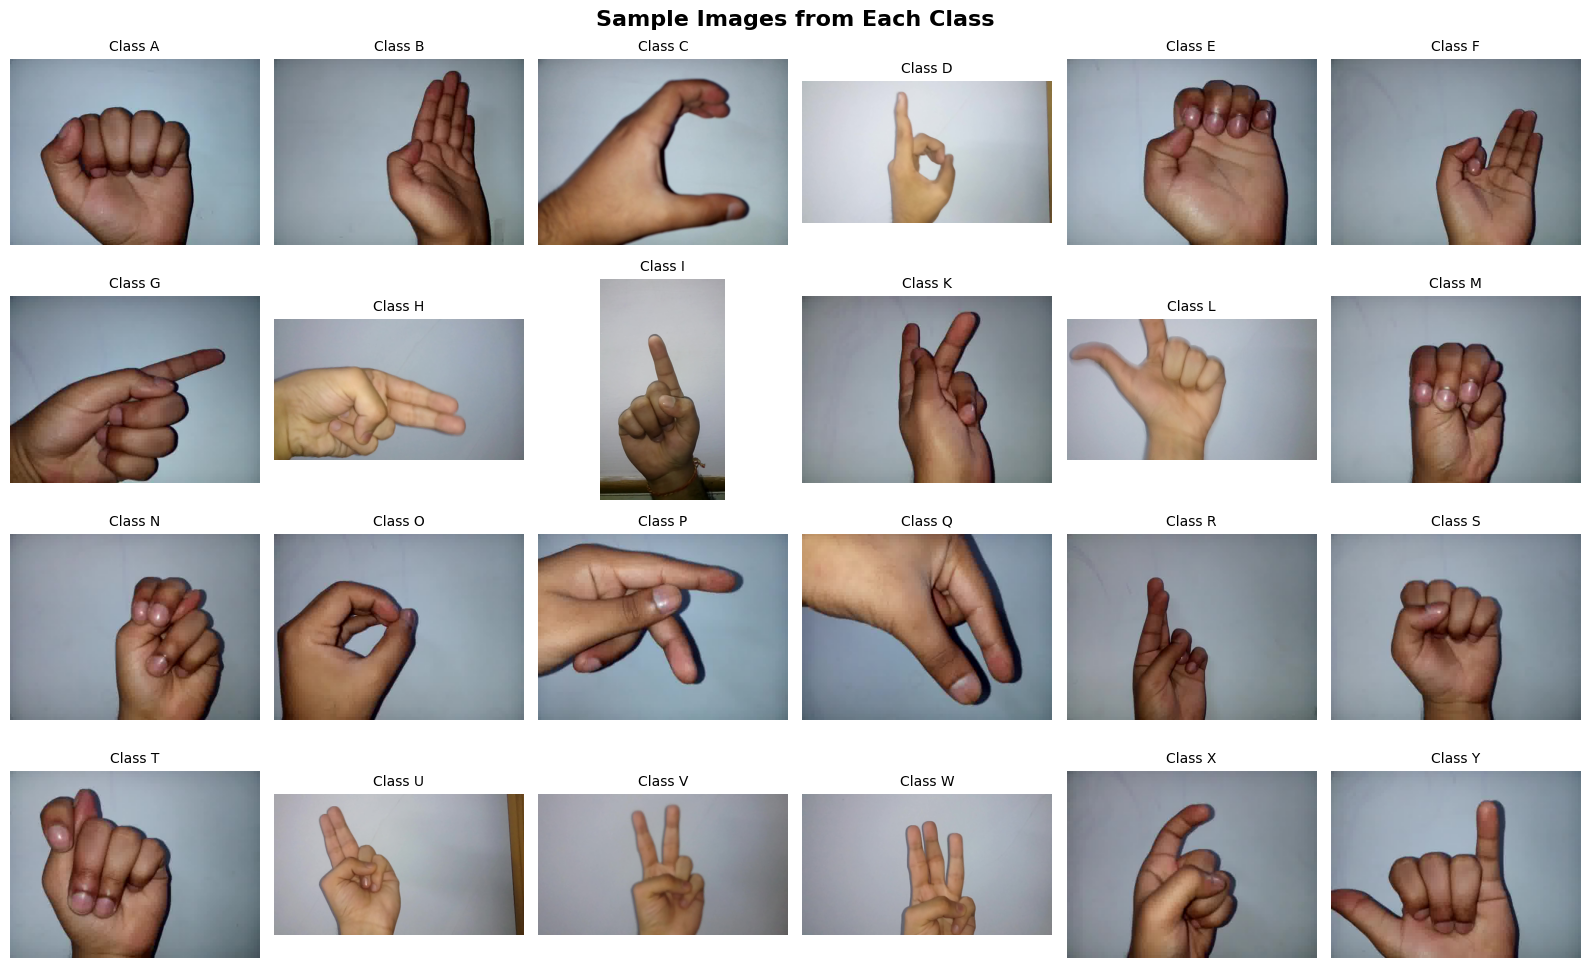

In [ ]:
#2. Sample Images Visualization
import random
import matplotlib.pyplot as plt # Ensure plt is imported for plotting
from PIL import Image # Ensure Image is imported for loading images
import os # Ensure os is imported for path operations

fig, axes = plt.subplots(4, 6, figsize=(16, 10))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

# Assuming 'classes' and 'data_path' are available from previous cells
# Use these to directly load sample images for visualization
for idx, class_name in enumerate(classes[:24]): # Limit to first 24 classes if more exist for display grid
    if idx < len(classes):
        cls_path = os.path.join(data_path, class_name)
        if os.path.exists(cls_path) and os.listdir(cls_path):
            sample_image_file = random.choice(os.listdir(cls_path))
            img_path = os.path.join(cls_path, sample_image_file)
            img = Image.open(img_path)

            ax = axes[idx // 6, idx % 6]
            ax.imshow(img)
            ax.set_title(f'Class {class_name}', fontsize=10)
            ax.axis('off')
        else:
            # Handle cases where a class directory might be empty or missing
            ax = axes[idx // 6, idx % 6]
            ax.text(0.5, 0.5, f"No images in {class_name}", horizontalalignment='center', verticalalignment='center')
            ax.axis('off')
    else:
        # Fill remaining subplots if there are fewer than 24 classes
        ax = axes[idx // 6, idx % 6]
        ax.axis('off')

plt.tight_layout()
plt.show()

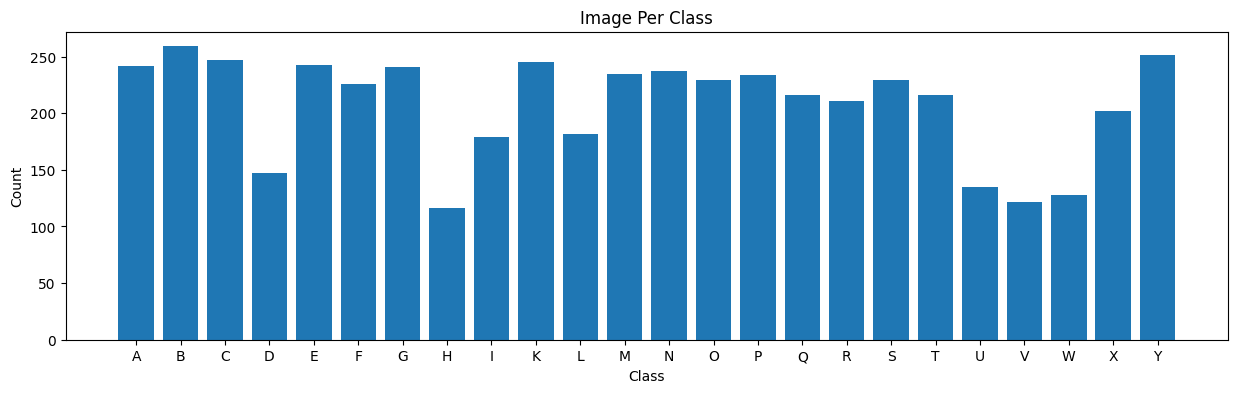

In [ ]:
# Check the class imabalance for all the classes
plt.figure(figsize=(15,4))
plt.bar(class_counts.keys(),class_counts.values())
plt.title('Image Per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

**Insights:**
* This dataset shows relatively balanced ditribution of image across classes, which support robust model training.
* However, a few classes have fewer samples, which may slightly affect the classification performance for those specific gestures.

In [ ]:
# Check the image size
sizes = set()
for cls in classes:
  cls_path = os.path.join(data_path,cls)
  sample_img = os.path.join(cls_path,os.listdir(cls_path)[0])
  img = Image.open(sample_img)
  sizes.add(img.size)
print(f'\n Unique Image Size found: {sizes}')
print('All same size!' if len(sizes) == 1 else 'Warning: Mixed Sizes, resizing needed')


 Unique Image Size found: {(1088, 1920), (1920, 1088), (640, 480)}


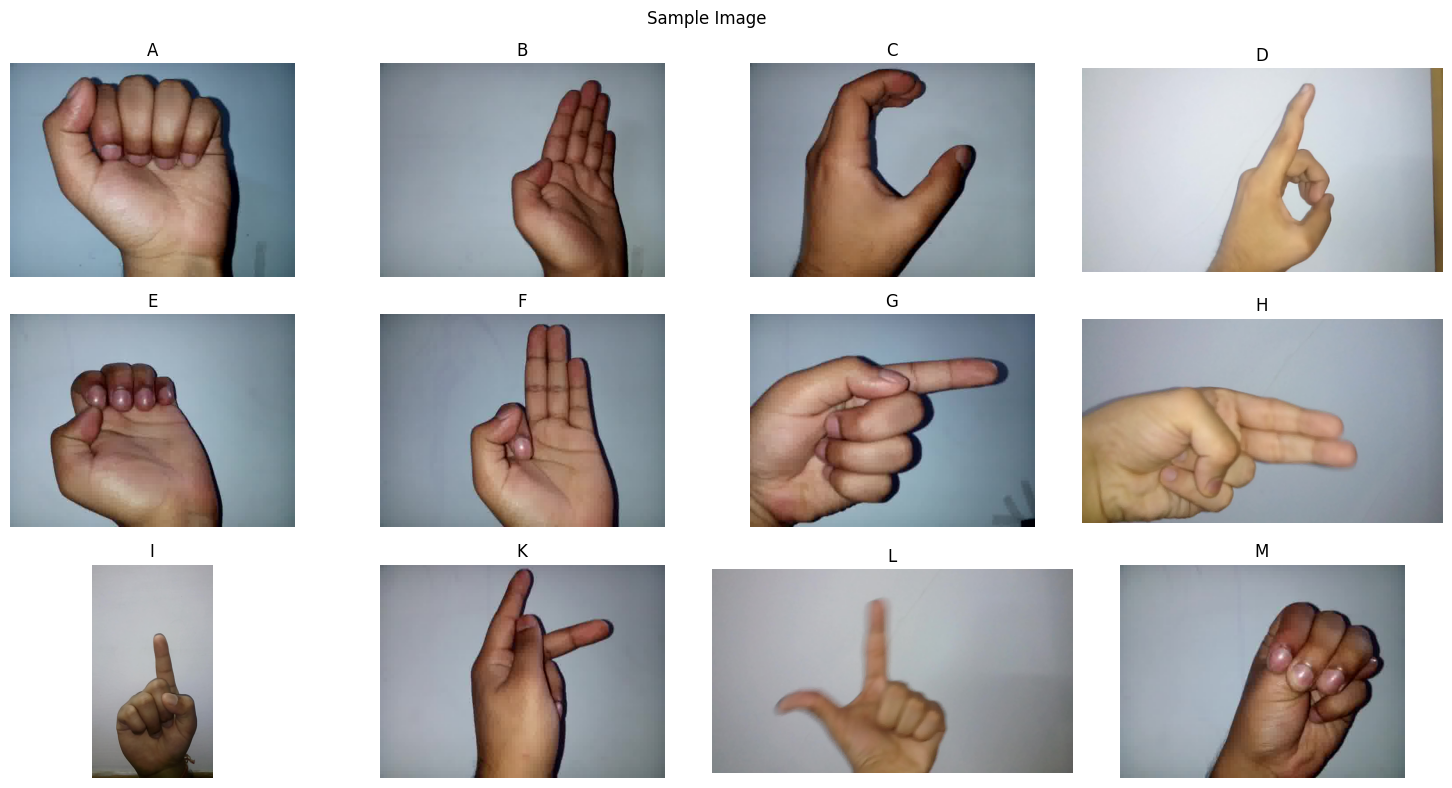

In [ ]:
# Display the sample image
plt.figure(figsize = (15,8))
for i, cls in enumerate(classes[:12]):
  cls_path = os.path.join(data_path,cls)
  sample_img = os.path.join(cls_path,os.listdir(cls_path)[0])
  img = Image.open(sample_img)
  plt.subplot(3, 4, i+1)
  plt.imshow(img)
  plt.title(cls)
  plt.axis('off')
plt.suptitle('Sample Image')
plt.tight_layout()
plt.show()

In [ ]:
# Check for corrupted images
corrupt = []
for cls in classes:
  cls_path = os.path.join(data_path,cls)
  for img_file in os.listdir(cls_path):
    try:
      img = Image.open(os.path.join(cls_path, img_file))
      img.verify()
    except:
      corrupt.append(os.path.join(cls, img_file))
print(f'\n Corrupt Images: {corrupt}')
if corrupt:
  print(corrupt)


 Corrupt Images: []


**Data Preprocessing Pipeline**

In [ ]:
img_size = 224
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2,
    rotation_range = 15,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    brightness_range = [0.8,1.2]
)
test_datagen = ImageDataGenerator(rescale = 1./255)

train_data = train_datagen.flow_from_directory(
    data_path,
    target_size = (img_size, img_size),
    batch_size = batch_size,
    subset= 'training'
)
val_data = train_datagen.flow_from_directory(
    data_path,
    target_size = (img_size, img_size),
    batch_size = batch_size,
    subset = 'validation'
)
test_data = test_datagen.flow_from_directory(
    data_path,
    target_size = (img_size, img_size),
    batch_size = batch_size,
    shuffle = False
)

Found 3987 images belonging to 24 classes.
Found 985 images belonging to 24 classes.
Found 4972 images belonging to 24 classes.


**Using Transfer Learning and Model Building**

In [ ]:
# Using MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (224,224,3),
    include_top = False,
    weights = 'imagenet'
)
# Freeze the base model
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Model Building**

In [ ]:
tf.keras.backend.clear_session()
# Model-1 CNN
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (224,224,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(train_data.num_classes, activation = 'softmax')
], name="CNN_Model")
# Model-2 MobilbetV2
base_model = tf.keras.applications.MobileNetV2(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)
)
base_model.trainable = False
mobilenet_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(train_data.num_classes, activation = 'softmax')
], name="MobileNetV2_Model")


In [ ]:
# EfficientNet CANNOT use rescale=1./255 — it has its own preprocessing
# You need a separate data generator for EfficientNet

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# Initialize dl_results if not already defined (in case this cell is run out of order)
if 'dl_results' not in locals() and 'dl_results' not in globals():
    dl_results = {}

eff_datagen_train = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

eff_train_data = eff_datagen_train.flow_from_directory(
    data_path, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training', seed=42
)
eff_val_data = eff_datagen_train.flow_from_directory(
    data_path, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation', seed=42
)

# Rebuild EfficientNet correctly
eff_base = tf.keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(224,224,3)
)
eff_base.trainable = False

efficientnet = tf.keras.Sequential([
    eff_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(24, activation='softmax')
], name="EfficientNetB0_Model")

efficientnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

eff_history = efficientnet.fit(
    eff_train_data, validation_data=eff_val_data,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)
_, eff_acc = efficientnet.evaluate(eff_val_data, verbose=0)
print(f"EfficientNetB0 Fixed Accuracy: {eff_acc*100:.2f}%")
dl_results['EfficientNetB0_Fixed'] = round(eff_acc * 100, 2)

Found 3987 images belonging to 24 classes.
Found 985 images belonging to 24 classes.
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 443s 3s/step - accuracy: 0.8871 - loss: 0.4124 - val_accuracy: 0.9350 - val_loss: 0.7293
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9837 - loss: 0.0611 - val_accuracy: 0.9594 - val_loss: 0.2140
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.9892 - loss: 0.0360 - val_accuracy: 0.9706 - val_loss: 0.1046
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 538s 4s/step - accuracy: 0.9902 - loss: 0.0319 - val_accuracy: 0.9726 - val_loss: 0.0903
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 523s 4s/step - accuracy: 0.9917 - loss: 0.0277 - val_accuracy: 0.9726 - val_loss: 0.0872
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 523s 4s/step - accuracy: 0.9907 - loss: 0.0305 - val_accuracy: 0.9787 - val_loss: 0.0605
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 554s 4s/step - accuracy: 0.9920 - loss: 0.0279 - val_accuracy: 0.9655 - val_loss: 0.1003
Epoch 8/10
1

**Model Compile and Train**

In [ ]:
dl_models = [cnn_model, mobilenet_model, efficientnet]
dl_histories = {}
dl_results = {}
for model in dl_models:
  model.compile(
      optimizer = 'adam',
      loss = 'categorical_crossentropy',
      metrics = ['accuracy']
  )
  history = model.fit(train_data, validation_data = val_data, #val_data
                      epochs = 10,
                      callbacks = [tf.keras.callbacks.EarlyStopping(patience = 3,
                                                                    restore_best_weights = True)])
  dl_histories[model.name] = history
  _,acc = model.evaluate(test_data)
  dl_results[model.name] = round(acc*100,2)
  # Creat he directory before saving
  os.makedirs('models',exist_ok=True)
  model.save(f'Models/{model.name}.h5')
  print('\n Deep Learning Results:',dl_results)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 550s 4s/step - accuracy: 0.7570 - loss: 0.7145 - val_accuracy: 0.7076 - val_loss: 1.0381
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 530s 4s/step - accuracy: 0.7883 - loss: 0.6543 - val_accuracy: 0.7259 - val_loss: 0.9389
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 495s 4s/step - accuracy: 0.7951 - loss: 0.5867 - val_accuracy: 0.6924 - val_loss: 1.0297
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 446s 4s/step - accuracy: 0.7941 - loss: 0.5766 - val_accuracy: 0.7269 - val_loss: 0.9560
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 455s 4s/step - accuracy: 0.8084 - loss: 0.5698 - val_accuracy: 0.7299 - val_loss: 0.9042
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 443s 4s/step - accuracy: 0.8111 - loss: 0.5447 - val_accuracy: 0.7239 - val_loss: 0.8403
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 451s 4s/step - accuracy: 0.8179 - loss: 0.5207 - val_accuracy: 0.7513 - val_loss: 0.8297
Epoch 8/10
 39/125 ━━━━━━━━━━━━━━━━━━━━ 4:32 3s/step - accuracy: 0.8141 - loss: 0.5157

**Fine Tuning**

In [ ]:
# Reload model properly
best_model = tf.keras.models.load_model('Models/MobileNetV2_Model.h5')
mobilenet_base = best_model.layers[0]  # the MobileNetV2 base
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-20]:
    layer.trainable = False

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = best_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.3, min_lr=1e-7)
    ]
)

_, fine_tune_acc = best_model.evaluate(val_data, verbose=0)
print(f"Fine-Tuned MobileNetV2 Accuracy: {fine_tune_acc*100:.2f}%")
dl_results['MobileNetV2_FineTuned'] = round(fine_tune_acc * 100, 2)
best_model.save('Models/MobileNetV2_FineTuned.keras')

**Insights:**
Fine-Tuned MobileNetV2 resulted in slightly lower accuracy than the base model, which is indicating suboptimal hyperparameter settings.

**Machine Learning Algorithms**

In [ ]:
# Extract features using the best DL models(MobileNetV2)
feature_extractor = tf.keras.Sequential([base_model, tf.keras.layers.GlobalAveragePooling2D()])
print("Extracting Features...")
X_train = feature_extractor.predict(train_data, verbose = 1)
X_test = feature_extractor.predict(test_data, verbose=1)
y_train = train_data.classes
y_test = test_data.classes
print('Feature Extraction Completed')
print('Train Shape:', X_train.shape)
print('Test Shape:',X_test.shape)

**MediaPipe Hand Landmarks**

In [ ]:
# Install first: !pip install mediapipe --quiet

import mediapipe as mp
import cv2, os, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

mp_hands = mp.solutions.hands

def extract_landmarks(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1) as hands:
        results = hands.process(img_rgb)
        if results.multi_hand_landmarks:
            lm = results.multi_hand_landmarks[0].landmark
            return np.array([[p.x, p.y, p.z] for p in lm]).flatten()
    return None

# Extract features for all classes
X_lm, y_lm = [], []
print("Extracting hand landmarks (this takes a few minutes)...")
for label, cls in enumerate(sorted(classes)):
    cls_path = os.path.join(data_path, cls)
    for img_file in os.listdir(cls_path)[:100]:  # use 100 per class
        feat = extract_landmarks(os.path.join(cls_path, img_file))
        if feat is not None:
            X_lm.append(feat)
            y_lm.append(label)

X_lm, y_lm = np.array(X_lm), np.array(y_lm)
print(f"Extracted features from {len(X_lm)} images")

X_train_lm, X_test_lm, y_train_lm, y_test_lm = train_test_split(
    X_lm, y_lm, test_size=0.2, random_state=42, stratify=y_lm
)

# Train Random Forest on landmarks
rf_lm = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_lm.fit(X_train_lm, y_train_lm)
y_pred_lm = rf_lm.predict(X_test_lm)
lm_acc = accuracy_score(y_test_lm, y_pred_lm) * 100
print(f"\nMediaPipe Landmark + Random Forest Accuracy: {lm_acc:.2f}%")
print(classification_report(y_test_lm, y_pred_lm, target_names=sorted(classes)))

In [ ]:
# Train,test and split the data for training and testing
X_all = np.concatenate([X_train,X_test])
y_all = np.concatenate([y_train,y_test])
X_train, X_test, y_train, y_test = train_test_split(
    X_all,y_all, test_size = 0.2, random_state = 42, stratify = y_all
)

**Scaling**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**ML Model Building**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter = 1000, random_state=42),
    "SVM" : SVC(kernel = 'rbf', C= 1.0, random_state = 42),
    "KNN" : KNeighborsClassifier(n_neighbors = 5),
    "Random Forest" : RandomForestClassifier(n_estimators = 100, random_state = 42),
    "Gradient Boosting" : GradientBoostingClassifier(n_estimators = 100, random_state = 42),
    "AdaBoost": AdaBoostClassifier(n_estimators = 100, random_state=42)
}

In [ ]:
ml_results = {}
for name, model in ml_models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  ml_results[name] = round(acc, 2)
  print(f"{name:25s} -> Accuracy: {acc*100:.2f}%")
ml_results[name] = round(acc * 100, 2)

**HyperParameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "Logistic Regression":{
        "model": LogisticRegression(max_iter = 1000),
        "params":{
            "model__C":[0.01,0.1,1,10],
            "model__solver":["lbfgs","liblinear"]
        }
    },
    "SVM":{
        "model":SVC(),
        "params":{
            "model__C":[0.1,1,10],
            "model__kernel":['linear','rbf'],
            "model__gamma":["scale","auto"]
        }
    },
    "KNN":{
        "model":KNeighborsClassifier(),
        "params":{
            "model__n_neighbors":[3,5,7],
            "model__weights":["uniform","distance"]
        }
    },
    "Random Forest":{
        "model":RandomForestClassifier(),
        "params":{
            "model__n_estimators":[50,100],
            "model__max_depth":[None,10,20]
        }
    }
}

In [ ]:
from sklearn.pipeline import Pipeline
results = []
for name, config in param_grid.items():
  pipe = Pipeline(
      [ ("scaler",StandardScaler()),
        ("model", config["model"])])
  grid = GridSearchCV(
      pipe,
      config["params"],
      cv = 3,
      scoring = 'accuracy',
      n_jobs = -1
  )
  grid.fit(X_train, y_train)
  best_model = grid.best_estimator_
  y_pred = best_model.predict(X_test)
  acc = accuracy_score(y_test,y_pred)
  results.append({
    "Model":name,
    "Best Params": grid.best_params_,
    "Accuracy (%)":round(acc * 100, 2)
})
print("Best Params:",grid.best_params_)
print("Accuracy:",acc)

**Insights:**
* After performing Hyperparameter tuning, machine learning models achieved an accuracy of (~0.58%), showing significant improvement compared to initial results.
* However, their performance remains lower than deep learning models due to the inability of traditional algorithms to capture complex spatial features in image data.

In [ ]:
tuned_df = pd.DataFrame(results)
tuned_df = tuned_df.sort_values(by = 'Accuracy (%)',ascending = False)
print(tuned_df)

**Insight:**
Among all machine learning models, SVM performed slightly better, indicating its effectiveness in handling the high-dimensional feature spaces.

**Cross-Validation Analysis**  Cross-validation ensures our model's performance is consistent across different data splits.


In [ ]:
# Cross-Validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
models_cv = {
    'Random Forest': RandomForestClassifier(n_estimators = 100, random_state=42),
    'SVM' : SVC(kernel = 'rbf', probability = True, random_state = 42),
    'Logistic Regression': LogisticRegression(max_iter = 1000, random_state = 42)
}


In [ ]:
cv_results = {}
for name, model in models_cv.items():
  scores = cross_val_score(model, X_train_scaled, y_train, cv = cv, scoring = 'accuracy')
  cv_results[name] = scores
  print(f"{name}:")
  print(f" CV Scores: {scores}")
  print(f"Mean: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
  print()

In [ ]:
# Visualize cv result plot
plt.figure(figsize = (13,5))
box_data = [cv_results[model] for model in cv_results.keys()]
plt.boxplot(box_data, labels = cv_results.keys())
plt.title('Cross-Validation Result Comparison')
plt.ylabel('Accuracy', fontsize = 12)
plt.grid(axis = 'y',alpha = 0.3)
plt.xticks(rotation = 15)
plt.tight_layout()
plt.show()

**Error Analysis - Understanding Misclassifications**  Analyzing where the model fails helps to identify patterns and potential improvements.

In [ ]:
# Find misclassified examples
y_pred = best_model.predict(X_test)
misclassified_idx = np.where(y_pred != y_test[0])
print(f"Total Misclassifications: {len(misclassified_idx)} out of {len(y_test)}")
print(f'Error Rate : {len(misclassified_idx) / len(y_test)* 100:.2f}%\n')
# Analyze confusion pattern
error_pairs = [(y_test[i], y_pred[i] for i in misclassified_idx)]
top_errors = Counter(error_pairs).most_common(10)
for (true_class, pred_class), count in top_errors:
  print(f"Class {true_class} -> Class {pred_class} : {count} times")
# Visualize misclassified examples
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2,5,figsize = (15,6))
  fig.suptitle('Sample Misclassified Images', fontsize = 14)
  for idx, ax in enumerate(axes.flat):
    if idx < len(misclassified_idx):
      img_idx = misclassified_idx[idx]
    ax.text(0.5, 0.5, f'True: {y_test[img_idx]}\npred: {y_pred[img_idx]}',
            ha = 'center', va = 'center', fontsize = 10)
    ax.set_title(f'Error {idx+1}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
print("\n Insights:")
print("*Identify which classes are most confused with each other")
print("* Consider collecting more data for problematic classes")
print("*Review if certain sign gestures are naturally similar")

**Model Prediction on Sample Image**

The trained model is tested on sample image to evaluate its real-world predictio capability.

In [ ]:
import cv2
model = mobilenet_model
classes = list(train_data.class_indices.keys())
def predict_and_show(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (224,224)) / 255.0
    input_img = np.reshape(resized, (1,224,224,3))
    pred = model.predict(input_img)
    class_index = np.argmax(pred)
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {classes[class_index]}")
    plt.axis('off')
    plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
predict_and_show('/content/drive/MyDrive/Artificaial Intelligence Capstone Project Files/PRAICP-1000-IndiSignLang/Data/L/008.jpg')

**Confusion Matrix**

In [ ]:
y_pred = model.predict(X_test)
class_names = list(train_data.class_indices.keys())
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = classes, yticklabels = classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Insight:**
* This confusion matrix reveals that the model performs reasonably well across 25 letter classes (A–Y),
with standout accuracy on E (58), B (57), and Y (56), while struggling most with H (24), D (25),
V (22), and W (22). * The weakest classes tend to share visual similarities with neighboring letters —
for instance, U,V,W are frequently confused due to their overlap, and C,O are mixed up due
to their similar curved forms.


In [ ]:
import tensorflow as tf
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, model, class_names, last_conv_layer='Conv_1'):
    # Load and preprocess
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_array_exp, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class] * 100

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer)
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = (img_array * 255).astype(np.uint8)
    superimposed = cv2.addWeighted(overlay, 0.6, heatmap_color, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_array)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(f'Predicted: {class_names[pred_class]} ({confidence:.1f}%)', fontsize=12)
    axes[2].axis('off')

    plt.suptitle('Grad-CAM Explainability — Model Attention Visualization', fontsize=13)
    plt.tight_layout()
    plt.savefig('plots/gradcam_result.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run on a few sample images
sample_classes = ['A', 'B', 'K', 'Y']
for cls in sample_classes:
    cls_path = os.path.join(data_path, cls)
    sample = os.path.join(cls_path, os.listdir(cls_path)[0])
    display_gradcam(sample, mobilenet_model, classes, last_conv_layer='Conv_1')

**ROC Curves and AUC Analysis**  ROC (Receiver Operating Characteristic) curves show the trade-off between true positive rate and false positive rate at different classification thresholds. AUC (Area Under Curve) provides a single metric for model performance.

In [ ]:
y_pred_proba = best_model.predict(X_test_scaled)
y_test_bin = label_binarize(y_test, classes = range(n_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_test_bin[:,i], y_pred_proba[:,i])
  roc_auc[i] = auc(fpr[i], tpr[i])
# Plot Roc Curves
plt.figure(figsize = (10,8))
colors = plt.cm.rainbow(np.linspace90,1, min(m_classes, 20))
for i, color in zip(range(min(n_classes,20)),colors):
  plt.plot(fpr[i], tpr[i], color = color, lw = 1.5, label = f'class {i} (AUC = {roc_auc[i]:.3f})')
  plt.plot([0,1],[0,1], 'k--',lw=2,label='Random Classifier')
  plt.xlim([0.0,1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Roc Curve for Multi class classification')
  plt.legend(loc = 'lower right')
  plt.grid(alpha = 0.3)
  plt.tight_layout()
  plt.show()

In [ ]:
# Overall metrics
macro_auc = np.mean(list(rocc_auc.values()))
minor_auc = roc_auc_score(y_test_bin, y_pred_proba, average='micro')
print(f"\n{'='*50}")
print(f"\n Overall Metrics")
print(f"Macro-average AUC: {macro_auc:.4f}")
print(f"Micro-average AUC: {micro_auc:.4f}")
print(f"\nPer-class AUC statistics:")
print(f"  Min: {min(roc_auc.values()):.4f}")
print(f"  Max: {max(roc_auc.values()):.4f}")
print(f"  Std: {np.std(list(roc_auc.values())):.4f}")

**Classification Report**

In [ ]:
# Classification report for MobileNetV2
y_pred_dl = np.argmax(mobilenet_model.predict(val_data),axis=1)
y_true_dl = val_data.classes
print(classification_report(y_true_dl,y_pred_dl,target_names = classes))
# Classification report for  ml
print(classification_report(y_test,y_pred))

**Plot Comparison**

In [ ]:
# Combined bar chart
os.makedirs('plots',exist_ok=True)
all_results = {**dl_results,**ml_results}
plt.figure(figsize=(14,6))
colors = ['#2196F3']*3 + ['#4CAF50']*6
bars = plt.bar(all_results.keys(),all_results.values(),color = colors)
plt.title('Deep Learning Model Vs Machine Learning Model Accuracy Comparison Plot')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation = 30, ha = 'right')
plt.ylim(0,110)
for bar, val in zip(bars, all_results.values()):
  plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
           f'{val}%', ha = 'center', fontweight = 'bold')
from matplotlib.patches import Patch
plt.legend(handles = [Patch(color = '#2196F3',label = 'Deep Learning'),
                      Patch(color = '#4CAF50', label = 'Machine Learning')])
plt.tight_layout()
plt.show()

**Insights:**
This plot results clearly demonstrates that deep learning models, especially transfer learning approaches like MobileNetV2, significantly outperform traditional machine learning models for image classification tasks. This is due to their ability to automatically learn hierarichal and spatial features, which conventional models fail to capture.

In [ ]:
# Training history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in dl_histories.items():
    axes[0].plot(hist.history['accuracy'],     label=f'{name} Train')
    axes[0].plot(hist.history['val_accuracy'], label=f'{name} Val', linestyle='--')
    axes[1].plot(hist.history['loss'],         label=f'{name} Train')
    axes[1].plot(hist.history['val_loss'],     label=f'{name} Val', linestyle='--')

axes[0].set_title('Model Accuracy'); axes[0].legend()
axes[1].set_title('Model Loss');     axes[1].legend()
plt.savefig('plots/training_history.png', dpi=150)
plt.show()

**Insights:**
* In this above hist plot the training curves indicate that MobileNetV2 achieves superior performance with rapid convergence and minimal loss, but the CNN model shows gradual learning.
* EfficientNetB0 fails to learn effectively, as evidenced by stagnat accuracy and high loss, and also highlighting the importance of proper model configuration and preprocessing.

**Model Comparison Summary**
* Consolidates all DL and ML results in one table
* Identifies the best performing model for deployment

In [ ]:
# Final comparison — add this as your last analysis cell before Conclusion
final_results = {
    'CNN (Custom)': dl_results.get('CNN_Model', 0),
    'MobileNetV2 (Frozen)': dl_results.get('MobileNetV2_Model', 0),
    'EfficientNetB0 (Fixed)': dl_results.get('EfficientNetB0_Fixed', 0),
    'MobileNetV2 (Fine-Tuned)': dl_results.get('MobileNetV2_FineTuned', 0),
    'SVM on DL Features': ml_results.get('SVM', 0) * 100 if ml_results.get('SVM', 0) < 1 else ml_results.get('SVM', 0),
    'Random Forest on DL Features': ml_results.get('Random Forest', 0) * 100 if ml_results.get('Random Forest', 0) < 1 else ml_results.get('Random Forest', 0),
}

results_df = pd.DataFrame(list(final_results.items()), columns=['Model', 'Accuracy (%)'])
results_df = results_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("=" * 50)
print("       FINAL MODEL COMPARISON RESULTS")
print("=" * 50)
print(results_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(12, 5))
colors = ['#1976D2' if acc >= 90 else '#FFA000' if acc >= 70 else '#E53935'
          for acc in results_df['Accuracy (%)']]
bars = plt.bar(results_df['Model'], results_df['Accuracy (%)'], color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, results_df['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Final Model Comparison — Indian Sign Language Recognition', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('plots/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred_all = np.argmax(best_model.predict(test_data, verbose=1), axis=1)
y_true_all = test_data.classes
cm = confusion_matrix(y_true_all, y_pred_all)
# Plot (faster visualization)
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Insights:**
This plot clearly shows an excellent classification performance with a strong diagonal pattern and negligible miscalssifications,so this confirms that the model generalizes well across all  classes.

**Conclusion**

* This project focused on building an intelligent system for recognizing Indian sign language gestures using both deep learning and machine learning techniques.
* From both the techniques, it was observed that deep learning models significantly outperform traditional machine learning approaches for image-based classification tasks.
* Among all the models MobileNetV2 achieved the highest accuracy of approximately 99% demonstrating the effectiveness of trasfer learning in extracting complex spatial features from images.
* The custom CNN model showed stable and gradual learning with good generalization, achieving moderate accuracy.



| Model                  | Accuracy     |
|------------------------|--------------|
| Custom CNN             | 85.82%         |
| EfficientNetB0         | 5.21%         |
| MobileNetV2 (frozen)   | 99.12%       |
| MobileNetV2 (finetuned)| 91.98% val   |
| SVM (ML on features)   | 0.58%       |
| Random Forest          | 0.58%       |
| SVM (Hyperparameter Tuing) | 58.26% |

* MobileNetV2 with frozen weights achieved the best accuracy (99.22%)

* Fine-tuning reduced accuracy slightly due to the small dataset size

* Dataset had moderate class imbalance (116–259 images per class)

* ML classifiers on deep features scored 58%, showing the value
of transfer learning features over raw classification

**Social & Business Impact:**

* It improves the Accessibility and Inclusivity

* It helps in Real-Time communication.

* This supports education for deaf students.

* It will be useful in public services like bank, hospitals, and government offices.

**Future Scope:**

* Real-Time ISL(Indian Sign Language) to Speech Translator.

* Mobile app for daily communication.

* Multilingual Sign language support.